# EDB simple example

This example shows how to use the ``EDBCommon`` class to
open an existing EDB project.

## Perform required imports

Perform the required imports.

In [1]:
import os
import shutil

In [2]:
from ansys.aedt.core import generate_unique_folder_name

In [3]:
from ansys.aedt.toolkits.common.utils import download_file
from ansys.aedt.toolkits.common.backend.api import EDBCommon

## Initialize temporary folder and project settings

Initialize a temporary folder to copy the input file into
and specify project settings.

In [4]:
URL_BASE = "https://raw.githubusercontent.com/ansys/example-data/master/toolkits/common/"
EDB_PROJECT = "edb_edge_ports.aedb/edb.def"
URL = os.path.join(URL_BASE, EDB_PROJECT)

temp_folder = os.path.join(generate_unique_folder_name())

edb_path = os.path.join(temp_folder, "edb_example.aedb")
os.makedirs(edb_path, exist_ok=True)
local_project = os.path.join(edb_path, "edb.def")

download_file(URL, local_project)

'C:\\Users\\ansys\\AppData\\Local\\Temp\\pyaedt_prj_MNU\\edb_example.aedb\\edb.def'

## Initialize toolkit

Initialize the toolkit.

In [5]:
toolkit = EDBCommon()

## Initialize EDB project

Open the EDB project.

In [6]:
load_edb_msg = toolkit.load_edb(edb_path)

C:\actions-runner\_work\pyaedt-toolkits-common\pyaedt-toolkits-common\.venv\Lib\site-packages\pyedb\generic\design_types.py:291: UserWarning: You are using PyEDB with grpc, which is currently in beta. Some feature might be missing or not working as expected. Please report any issue you find to the PyEDB team.
  warnings.warn(GRPC_BETA_WARNING, UserWarning)
C:\actions-runner\_work\pyaedt-toolkits-common\pyaedt-toolkits-common\.venv\Lib\site-packages\pyedb\grpc\edb.py:2542: SyntaxWarning: invalid escape sequence '\T'
  >>> edb_zones = edb.copy_zones(r"C:\Temp\test")


C:\actions-runner\_work\pyaedt-toolkits-common\pyaedt-toolkits-common\.venv\Lib\site-packages\pyedb\generic\constants.py:212: SyntaxWarning: invalid escape sequence '\d'
  loc = re.search("[-+]?(\d+(\.\d*)?|\.\d+)([eE][-+]?\d+)?", variable_value)
C:\actions-runner\_work\pyaedt-toolkits-common\pyaedt-toolkits-common\.venv\Lib\site-packages\pyedb\grpc\database\components.py:2088: SyntaxWarning: invalid escape sequence '\m'
  >>> edb_file = r"C:\my_edb_file.aedb"


PyEDB INFO: Logger is initialized in EDB.


PyEDB INFO: legacy v0.71.0


PyEDB INFO: Python version 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


...

PyEDB INFO: Database edb_example.aedb Opened in 2026.1


PyEDB INFO: Cell EMDesign1 Opened


PyEDB INFO: Refreshing the Components dictionary.


PyEDB INFO: Builder was initialized.


PyEDB INFO: EDB initialized.


## Get toolkit properties

Get toolkit properties, which contain the project information.

In [7]:
new_properties = toolkit.get_properties()
edb_project = new_properties["active_project"]

## Save project

Copy the current project in a new file.

In [8]:
directory, old_file_name = os.path.split(edb_project)
new_path = os.path.join(directory, "new_edb.aedb")
toolkit.save_edb(new_path)

INFO - Project C:\Users\ansys\AppData\Local\Temp\pyaedt_prj_MNU\new_edb.aedb saved


True

## Get cell names

Get cell names using PyEDB.

INFO - Play with EDB


_MultiThreadedRendezvous: <_MultiThreadedRendezvous of RPC that terminated with:
	status = StatusCode.INVALID_ARGUMENT
	details = "Illegal operation on a null LayoutInstance object"
	debug_error_string = "UNKNOWN:Error received from peer  {grpc_message:"Illegal operation on a null LayoutInstance object", grpc_status:3}"
>

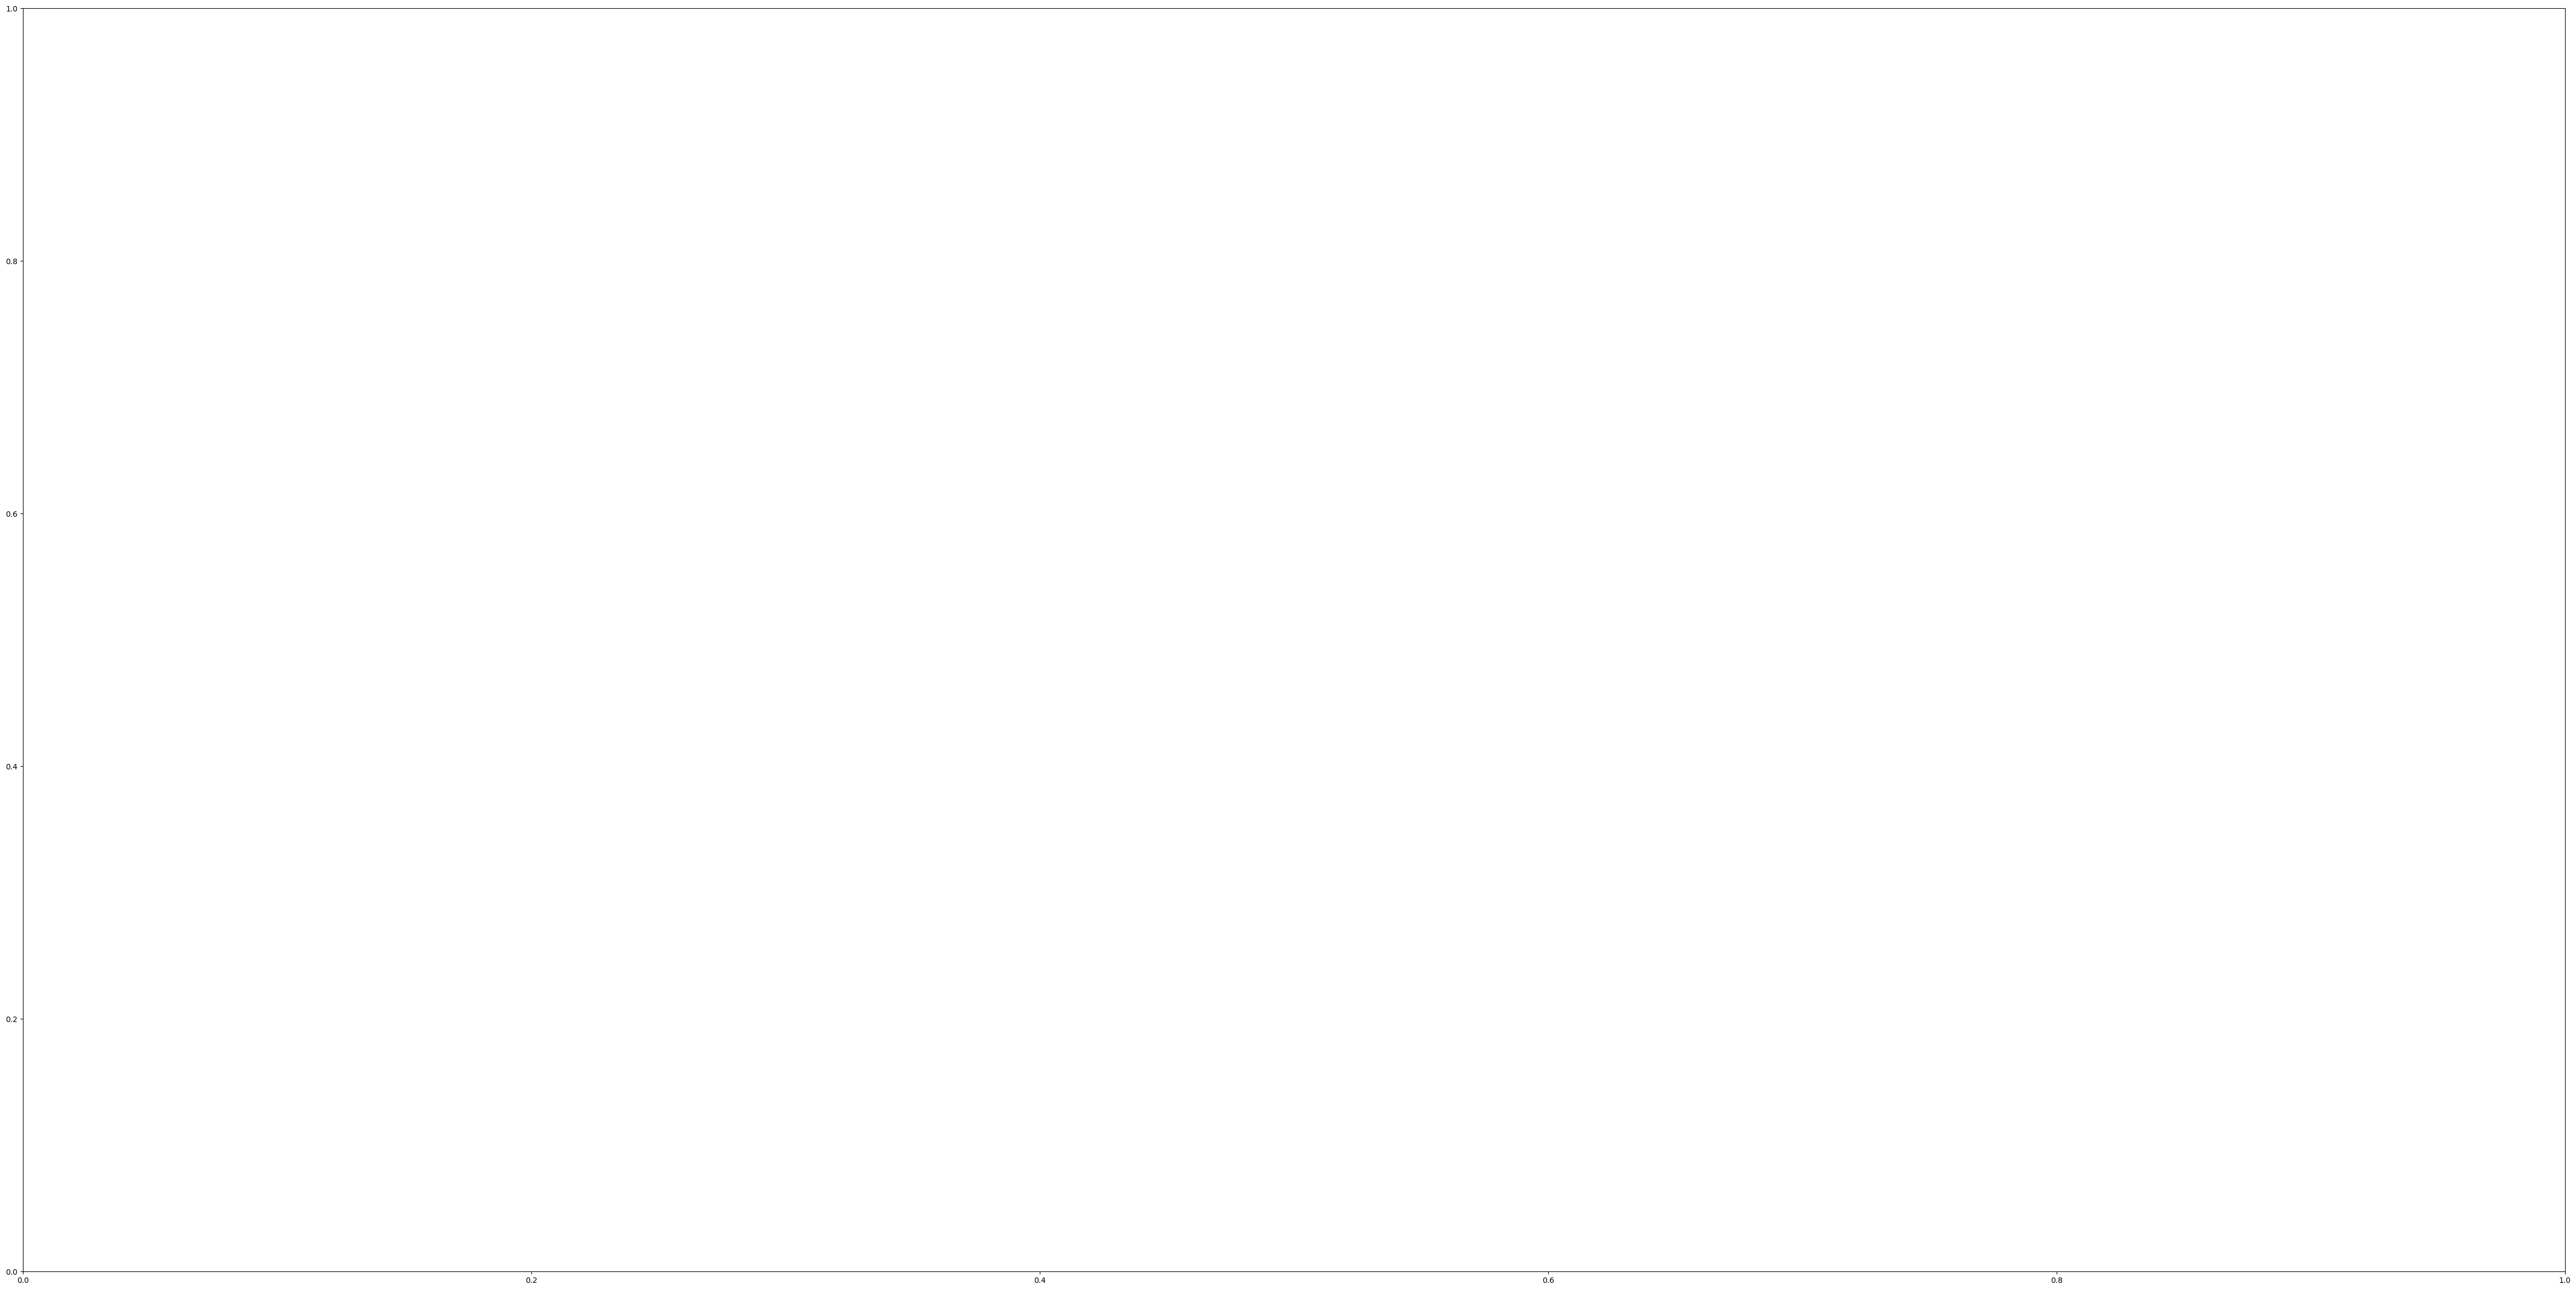

In [9]:
toolkit.logger.info("Play with EDB")
cell_names = toolkit.edb.cell_names
toolkit.edb.nets.plot()

## Save and release EDB

Save and release EDB.

In [10]:
toolkit.close_edb()

INFO - EDB is closed.


True

## Remove temporary folder

Remove the temporary folder.

In [11]:
shutil.rmtree(temp_folder, ignore_errors=True)